# Immobilier Tunisien — Pipeline Data Science
### `NLP → Nettoyage → Prédiction de Prix`

---
**Structure du notebook**
```
PARTIE 1 — NLP          : détection pays, extraction features depuis le texte brut
PARTIE 2 — NETTOYAGE    : prix, surface, doublons, feature engineering
PARTIE 3 — PRÉDICTION   : pipeline sklearn, 4 modèles, cross-validation, ensemble
```

In [2]:
!pip install openpyxl scikit-learn -q

import pandas as pd
import numpy as np
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.0f}'.format)

print('✓ Imports OK')

✓ Imports OK


In [3]:

# ── Upload du fichier Excel ──
from google.colab import files

print('📂 Clique sur "Choisir des fichiers" ci-dessous')
uploaded = files.upload()

FILE_PATH = list(uploaded.keys())[0]
print(f'✓ Fichier chargé : {FILE_PATH}')

📂 Clique sur "Choisir des fichiers" ci-dessous


Saving final_listings_report (1).xlsx to final_listings_report (1).xlsx
✓ Fichier chargé : final_listings_report (1).xlsx


In [4]:
df_raw = pd.read_excel(FILE_PATH)
print(f'Shape : {df_raw.shape}')
df_raw.head(3)

Shape : (3680, 19)


,website_id,title,price,currency,city,zone,property_type,transaction_type,surface_m2,rooms,bathrooms,description,agency_owner,phone,listing_url,data_hash,image_urls,published_date,scraped_at
0,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 Ain Zaghouan Nord - 1...,1,TND,Tunis,NaN,NaN,NaN,115,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,4262fa565db01f790e98080dc698ec35,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:30.841
1,698b18a6c43bfefaf2694c1e,À vendre duplex S+3 Jardins de Carthage - 307 m²,1,TND,Tunis,NaN,NaN,NaN,307,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-duplex-...,b9b8581e5189e7059877a8424d47a018,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:34.661
2,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 La Soukra - 113 m²,1,TND,Tunis,NaN,NaN,NaN,113,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,9e6f5b4dbc3b7ae4834b8ee301439a5d,['https://century21.tn/wp-content/uploads/c704...,NaN,2026-02-10 21:01:38.071


---
## PARTIE 1 — NLP
### Objectif : extraire de l'information structurée depuis du texte brut

Les colonnes `property_type`, `transaction_type`, `zone` sont **vides dans la source**.
On les reconstruit depuis le titre et l'URL via :
- **Détection de pays** : domaine TLD + keywords
- **Regex** : patterns `S+N`, `NNN m²`, `/a-vendre`
- **Dictionnaire** : mapping lexical pour le type de bien

```
Titre brut : "À vendre appartement S+2 Ain Zaghouan Nord - 115 m²"
             ──────┬──────  ─────┬──────  ──┬──  ──────┬──────   ─┬─
                   │             │           │          │           │
          transaction         type        rooms       zone      surface
```

In [5]:
# ════════════════════════════════════════════════════════════
#  1.1 — DÉTECTION DE PAYS (signal domaine + fallback NLP)
# ════════════════════════════════════════════════════════════

# Domaines officiellement étrangers dans notre dataset
FR_DOMAINS = re.compile(r'century21\.fr|green-acres\.fr|seloger|leboncoin|pap\.fr', re.I)
MA_DOMAINS = re.compile(r'mubawab\.ma', re.I)
TN_DOMAINS = re.compile(r'\.tn$|\.com\.tn$', re.I)

# Keywords NLP pour trancher les domaines ambigus (.com, .net...)
TN_KW = [
    'tunis','ariana','nabeul','sousse','sfax','monastir','mahdia','hammamet',
    'djerba','carthage','la marsa','berges du lac','ennasr','menzah','chotrana',
    'soukra','ain zaghouan','kairouan','bizerte','mednine','tataouine','gabes',
    'gabès','kef','tozeur','gafsa','jendouba','beja','sidi bouzid','ben arous',
    'manouba','tnd','montplaisir','sidi daoud','mrezga','sahloul','kerkennah',
    'zarzis','sidi bou said','el aouina','cite ennasr','jardins de carthage',
]
MA_KW = [
    'marrakech','casablanca','rabat','agadir','fes','tanger','kenitra',
    'oujda','hivernage','maroc','dh ','mad ',
]
FR_KW = [
    'paris','lyon','marseille','bordeaux','toulouse','nice','nantes','strasbourg',
    'montpellier','rennes','lille','grenoble','limoges','dijon','troyes','rouen',
    'reims','amiens','caen','argenteuil','bretagne','basque',' euros ',' € ',
]

def detect_country(row) -> str:
    """
    Retourne 'TN' | 'FR' | 'MA' | 'OTHER'

    Priorité : domaine TLD → keywords MA/FR → keywords TN
    """
    url    = str(row.get('listing_url', '') or '')
    m      = re.match(r'https?://(?:www\.)?([^/]+)', url)
    domain = m.group(1).lower() if m else ''
    text   = ' '.join([
        str(row.get('title', '')       or ''),
        str(row.get('description', '') or ''),
        str(row.get('city', '')        or ''),
    ]).lower()

    # Signal fort : TLD du domaine
    if TN_DOMAINS.search(domain):  return 'TN'
    if FR_DOMAINS.search(domain):  return 'FR'
    if MA_DOMAINS.search(domain):  return 'MA'

    # Fallback NLP sur le texte (pour les .com, .net...)
    if any(kw in text for kw in MA_KW): return 'MA'
    if any(kw in text for kw in FR_KW): return 'FR'
    if any(kw in text for kw in TN_KW): return 'TN'
    if str(row.get('currency', '')).upper() == 'TND': return 'TN'

    return 'OTHER'  # inclassable → on garde (peut être TN sans indice fort)

Distribution pays détectés :
country
TN    2688
MA     523
FR     469


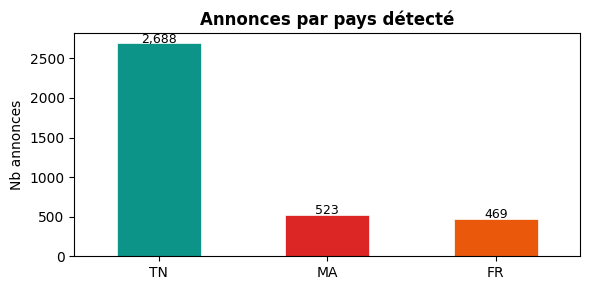

In [6]:
df_raw['country'] = df_raw.apply(detect_country, axis=1)

print('Distribution pays détectés :')
print(df_raw['country'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 3))
vc = df_raw['country'].value_counts()
colors = ['#0D9488','#DC2626','#EA580C','#6B7280']
vc.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Annonces par pays détecté', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Nb annonces')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height() + 10),
                ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# ════════════════════════════════════════════════════════════
#  1.2 — EXTRACTION NLP DES FEATURES DEPUIS LE TITRE
# ════════════════════════════════════════════════════════════

# --- transaction_type ---
def extract_transaction(title: str, url: str = '') -> str:
    """
    Détecte Vente / Location depuis le titre et l'URL.
    L'URL est plus fiable : /a-vendre, /a-louer
    """
    src = (str(title or '') + ' ' + str(url or '')).lower()
    if re.search(r'\bvendr[e]?\b|\bvente\b|\bvend\b|a[ -]vendre|/a-vendre', src):
        return 'Vente'
    if re.search(r'\bloue[r]?\b|\blocation\b|a[ -]louer|/a-louer', src):
        return 'Location'
    return 'Inconnu'


# --- property_type ---
PROPERTY_DICT = {
    'appartement': 'Appartement', 'duplex':  'Duplex',    'triplex': 'Triplex',
    'penthouse':   'Penthouse',   'studio':  'Studio',    'loft':    'Loft',
    'villa':       'Villa',       'maison':  'Maison',    'riad':    'Riad',
    'bureau':      'Bureau',      'local':   'Local com', 'magasin': 'Magasin',
    'entrepôt':    'Entrepôt',    'entrepot':'Entrepôt',  'hangar':  'Hangar',
    'immeuble':    'Immeuble',    'terrain': 'Terrain',   'ferme':   'Ferme',
    'parking':     'Parking',     'garage':  'Garage',
}

def extract_property_type(title: str, url: str = '') -> str:
    src = (str(title or '') + ' ' + str(url or '')).lower()
    for key, val in PROPERTY_DICT.items():
        if key in src:
            return val
    return 'Autre'


# --- rooms depuis pattern S+N ---
def extract_rooms(title: str) -> float | None:
    """
    S+2 → 3 pièces  |  H+3 (bureaux) → 4 pièces
    """
    t = str(title or '').upper()
    m = re.search(r'\bS\s*\+\s*(\d+)\b', t)
    if m: return int(m.group(1)) + 1
    m = re.search(r'\b[HA]\s*\+\s*(\d+)\b', t)   # bureaux : H+2, A+3
    if m: return int(m.group(1)) + 1
    return None


# --- surface depuis titre ou description ---
def extract_surface(title: str, description: str = '') -> float | None:
    """
    Cherche 'NNN m²' dans le titre d'abord, puis dans la description.
    Filtre : 5 ≤ surface ≤ 20 000 m²
    """
    for src in [str(title or ''), str(description or '')]:
        m = re.search(r'(\d[\d\s]*)\s*m[²2]', src, re.IGNORECASE)
        if m:
            try:
                v = int(re.sub(r'\s', '', m.group(1)))
                if 5 <= v <= 20_000:
                    return float(v)
            except ValueError:
                pass
    return None


# --- zone / quartier ---
def extract_zone(title: str) -> str | None:
    """
    Extrait le quartier depuis le pattern :
    'Appartement S+2  <ZONE>  - 115 m²'
    """
    t = str(title or '')
    m = re.search(
        r'(?:S\+\d+|[HA]\+\d+|studio|duplex|villa|appartement)\s+(.+?)'
        r'(?:\s*[-–]\s*\d+\s*m[²2]|$)',
        t, re.IGNORECASE
    )
    if m:
        zone = re.sub(r'\d+\s*m[²2].*', '', m.group(1), flags=re.IGNORECASE).strip('- ')
        if 3 <= len(zone) <= 60 and not re.match(r'^\d+$', zone):
            return zone
    return None

In [8]:
# Application sur le dataset brut (avant filtrage géographique)
# → on applique NLP sur tout, on filtre après

df_raw['_transaction_nlp'] = df_raw.apply(
    lambda r: extract_transaction(r['title'], r.get('listing_url', '')), axis=1
)
df_raw['_property_nlp'] = df_raw.apply(
    lambda r: extract_property_type(r['title'], r.get('listing_url', '')), axis=1
)
df_raw['_rooms_nlp']   = df_raw['title'].apply(extract_rooms)
df_raw['_surface_nlp'] = df_raw.apply(
    lambda r: extract_surface(r['title'], r.get('description', '')), axis=1
)
df_raw['_zone_nlp'] = df_raw['title'].apply(extract_zone)

# Résumé NLP
n = len(df_raw)
print('─── Taux de couverture NLP (sur tout le dataset) ───')
print(f"  transaction_type : {(df_raw['_transaction_nlp'] != 'Inconnu').sum():>5} / {n}  "
      f"({(df_raw['_transaction_nlp'] != 'Inconnu').mean()*100:.1f}%)")
print(f"  property_type    : {(df_raw['_property_nlp'] != 'Autre').sum():>5} / {n}  "
      f"({(df_raw['_property_nlp'] != 'Autre').mean()*100:.1f}%)")
print(f"  rooms (S+N)      : {df_raw['_rooms_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_rooms_nlp'].notna().mean()*100:.1f}%)")
print(f"  surface (m²)     : {df_raw['_surface_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_surface_nlp'].notna().mean()*100:.1f}%)")
print(f"  zone/quartier    : {df_raw['_zone_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_zone_nlp'].notna().mean()*100:.1f}%)")

─── Taux de couverture NLP (sur tout le dataset) ───
  transaction_type :  2314 / 3680  (62.9%)
  property_type    :  2855 / 3680  (77.6%)
  rooms (S+N)      :   545 / 3680  (14.8%)
  surface (m²)     :   519 / 3680  (14.1%)
  zone/quartier    :  1265 / 3680  (34.4%)


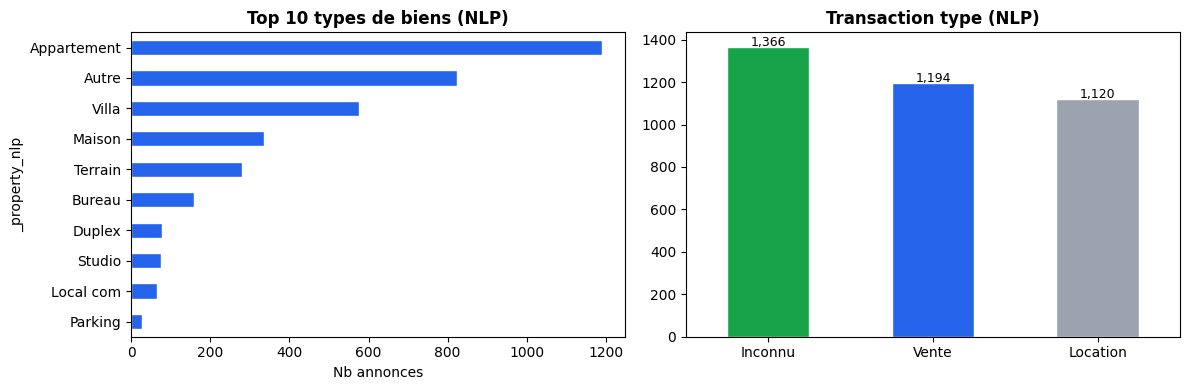

In [9]:
# Visualisation : distribution des types de biens extraits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# property_type
pt = df_raw['_property_nlp'].value_counts().head(10)
pt.plot(kind='barh', ax=axes[0], color='#2563EB', edgecolor='white')
axes[0].set_title('Top 10 types de biens (NLP)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Nb annonces')

# transaction_type
tt = df_raw['_transaction_nlp'].value_counts()
colors_tt = ['#16A34A', '#2563EB', '#9CA3AF']
tt.plot(kind='bar', ax=axes[1], color=colors_tt, edgecolor='white')
axes[1].set_title('Transaction type (NLP)', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_xticklabels(tt.index, rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## PARTIE 2 — NETTOYAGE
### Objectif : produire un dataset fiable pour le ML

Pipeline de nettoyage :
```
① Filtrage géographique   → on garde uniquement la Tunisie
② Merge NLP → colonnes    → on consolide les features extraites
③ Nettoyage prix          → règles métier par type de transaction
④ Nettoyage surface       → bornes physiques réalistes
⑤ Déduplication           → hash exact + (titre, prix)
⑥ Feature engineering     → 10 nouvelles colonnes pour le ML
```

In [10]:
# ════════════════════════════════════════════════════════════
#  2.1 — FILTRAGE GÉOGRAPHIQUE
# ════════════════════════════════════════════════════════════

df = df_raw[df_raw['country'].isin(['TN', 'OTHER'])].copy()

removed = df_raw[~df_raw['country'].isin(['TN', 'OTHER'])]
print(f'Supprimés : {len(removed)} annonces non-tunisiennes')
print(removed['country'].value_counts().to_string())
print(f'\nDataset Tunisie : {len(df)} annonces')

Supprimés : 992 annonces non-tunisiennes
country
MA    523
FR    469

Dataset Tunisie : 2688 annonces


In [11]:
# ════════════════════════════════════════════════════════════
#  2.2 — CONSOLIDATION : colonnes existantes + NLP
# ════════════════════════════════════════════════════════════
#
# Règle : valeur source garde la priorité si elle est non-nulle.
# Si nulle → on prend la valeur extraite par NLP.

# transaction_type & property_type : toutes nulles en source → 100% NLP
df['transaction_type'] = df['_transaction_nlp']
df['property_type']    = df['_property_nlp']

# rooms : source a des 0 qu'on traite comme null
rooms_src = pd.to_numeric(df['rooms'], errors='coerce').replace(0, np.nan)
df['rooms'] = rooms_src.combine_first(df['_rooms_nlp'])

# surface : même logique
surf_src = pd.to_numeric(df['surface_m2'], errors='coerce').replace(0, np.nan)
df['surface_m2'] = surf_src.combine_first(df['_surface_nlp'])

# zone
df['zone'] = df['zone'].combine_first(df['_zone_nlp'])

# Normalisation ville
CITY_MAP = {
    'tunis':'Tunis','ariana':'Ariana','ben arous':'Ben Arous','nabeul':'Nabeul',
    'sousse':'Sousse','sfax':'Sfax','monastir':'Monastir','mahdia':'Mahdia',
    'hammamet':'Hammamet','djerba':'Djerba','bizerte':'Bizerte','kairouan':'Kairouan',
    'gabes':'Gabès','gabès':'Gabès','mednine':'Médenine','tataouine':'Tataouine',
    'gafsa':'Gafsa','tozeur':'Tozeur','la marsa':'La Marsa','manouba':'Manouba',
    'zaghouan':'Zaghouan','sidi bouzid':'Sidi Bouzid','jendouba':'Jendouba',
}
def normalize_city(c):
    if pd.isna(c): return np.nan
    cl = str(c).lower().strip()
    for k, v in CITY_MAP.items():
        if k in cl: return v
    return str(c).strip().title()

df['city'] = df['city'].apply(normalize_city)

# Nettoyage colonnes intermédiaires NLP
df.drop(columns=[c for c in df.columns if c.startswith('_')], inplace=True)

print('Consolidation terminée.')
print(df[['transaction_type','property_type','rooms','surface_m2','zone','city']].info())

Consolidation terminée.
<class 'pandas.core.frame.DataFrame'>
Index: 2688 entries, 0 to 3679
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_type  2688 non-null   object 
 1   property_type     2688 non-null   object 
 2   rooms             1319 non-null   float64
 3   surface_m2        2202 non-null   float64
 4   zone              835 non-null    object 
 5   city              2619 non-null   object 
dtypes: float64(2), object(4)
memory usage: 211.5+ KB
None


In [12]:
# ════════════════════════════════════════════════════════════
#  2.3 — NETTOYAGE DES PRIX
# ════════════════════════════════════════════════════════════
#
# Règles métier (en TND) :
#   Vente    : [15 000 — 10 000 000]
#   Location : [200   — 100 000]
#   Inconnu  : [200   — 10 000 000]

PRICE_BOUNDS = {
    'Vente':    (15_000, 10_000_000),
    'Location': (200,    100_000),
    'Inconnu':  (200,    10_000_000),
}

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price_original'] = df['price'].copy()  # conservation de la valeur brute

def clean_price(row):
    p, t = row['price'], row['transaction_type']
    if pd.isna(p) or p <= 0:
        return np.nan
    lo, hi = PRICE_BOUNDS.get(t, (200, 10_000_000))
    return p if lo <= p <= hi else np.nan

df['price'] = df.apply(clean_price, axis=1)

# Diagnostique
n_total  = len(df)
n_valid  = df['price'].notna().sum()
n_null   = df['price_original'].isna().sum() + (df['price_original'] <= 0).sum()
n_bounds = n_total - n_valid - n_null

print(f'Prix valides : {n_valid:,} / {n_total:,}')
print(f'Null / zéro  : {n_null:,}')
print(f'Hors bornes  : {n_bounds:,}')
print()
print('Statistiques prix valides (Vente) :')
print(df[df['transaction_type']=='Vente']['price'].describe().apply('{:,.0f}'.format))

Prix valides : 1,482 / 2,688
Null / zéro  : 550
Hors bornes  : 656

Statistiques prix valides (Vente) :
count           402
mean        700,483
std       1,021,759
min          15,600
25%         250,000
50%         450,000
75%         796,000
max      10,000,000
Name: price, dtype: object


In [13]:
# ════════════════════════════════════════════════════════════
#  2.4 — NETTOYAGE SURFACE + DÉDUPLICATION
# ════════════════════════════════════════════════════════════

df['surface_m2'] = pd.to_numeric(df['surface_m2'], errors='coerce')
df.loc[(df['surface_m2'] <= 0) | (df['surface_m2'] > 15_000), 'surface_m2'] = np.nan

n_before = len(df)
df = df.drop_duplicates(subset='data_hash')
df = df.drop_duplicates(subset=['title', 'price'], keep='first')
n_dupes = n_before - len(df)

print(f'Doublons supprimés : {n_dupes}')
print(f'Dataset final      : {len(df):,} annonces')

Doublons supprimés : 552
Dataset final      : 2,136 annonces


In [14]:
# ════════════════════════════════════════════════════════════
#  2.5 — FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════
#
# On crée des features informatives pour le modèle ML.
# Chaque feature a une justification métier.

# F1 : prix au m² — indicateur de valeur relatif
df['price_per_m2'] = np.where(
    df['price'].notna() & df['surface_m2'].notna() & (df['surface_m2'] > 0),
    df['price'] / df['surface_m2'],
    np.nan
)

# F2 : log(surface) — la surface a une distribution log-normale
df['log_surface'] = np.log1p(df['surface_m2'].fillna(0))

# F3 : pièces imputées — S+N depuis titre, sinon surface/25 (heuristique)
df['rooms_imp'] = df['rooms'].fillna(
    (df['surface_m2'].fillna(0) / 25).round().clip(1, 12)
)

# F4 : SDB imputées
df['bath_imp'] = df['bathrooms'].replace(0, np.nan).fillna(
    (df['rooms_imp'] / 3).round().clip(0, 5)
)

# F5 : prix/m² médian par type de bien — proxy de la valeur du segment
pm2_by_type = (
    df[df['price_per_m2'].between(100, 30_000)]
    .groupby('property_type')['price_per_m2'].median()
)
df['ref_pm2'] = df['property_type'].map(pm2_by_type).fillna(df['price_per_m2'].median())

# F6 : bucket surface (catégoriel ordonné)
df['surface_cat'] = pd.cut(
    df['surface_m2'],
    bins=[0, 50, 80, 120, 200, 400, 20_000],
    labels=['<50m²','50-80','80-120','120-200','200-400','>400m²']
).astype(str).replace('nan', 'Inconnu')

# F7-F9 : flags textuels (meublé, neuf, piscine)
df['is_furnished'] = df['title'].str.contains(r'meublé|meuble', case=False, na=False).astype(int)
df['is_new']       = df['title'].str.contains(r'\bneuf\b|\bneuve\b|\bstanding\b', case=False, na=False).astype(int)
df['has_pool']     = df.apply(
    lambda r: int(bool(re.search(r'piscine|pool',
                                  str(r['title'] or '') + str(r.get('description','') or ''),
                                  re.I))),
    axis=1
)

# F10 : tier de la ville (liquidité du marché)
CITY_TIER = {
    'Tunis': 1, 'Ariana': 1, 'La Marsa': 1,
    'Ben Arous': 2, 'Nabeul': 2, 'Hammamet': 2, 'Sousse': 2, 'Sfax': 2,
    'Monastir': 2, 'Mahdia': 3, 'Bizerte': 3, 'Kairouan': 3,
    'Djerba': 3, 'Gabès': 3,
}
df['city_tier'] = df['city'].map(CITY_TIER).fillna(4).astype(int)

print('Features engineering — aperçu :')
fe_cols = ['price_per_m2','log_surface','rooms_imp','bath_imp','ref_pm2',
           'surface_cat','is_furnished','is_new','has_pool','city_tier']
print(df[fe_cols].describe().round(2).T[['count','mean','min','max']].to_string())

Features engineering — aperçu :
              count  mean  min       max
price_per_m2  1,052 7,690    0 2,100,000
log_surface   2,136     4    0        10
rooms_imp     2,136    13    1     1,700
bath_imp      2,136     2    0         5
ref_pm2       2,136 2,168  549     5,841
is_furnished  2,136     0    0         1
is_new        2,136     0    0         1
has_pool      2,136     0    0         1
city_tier     2,136     1    1         4


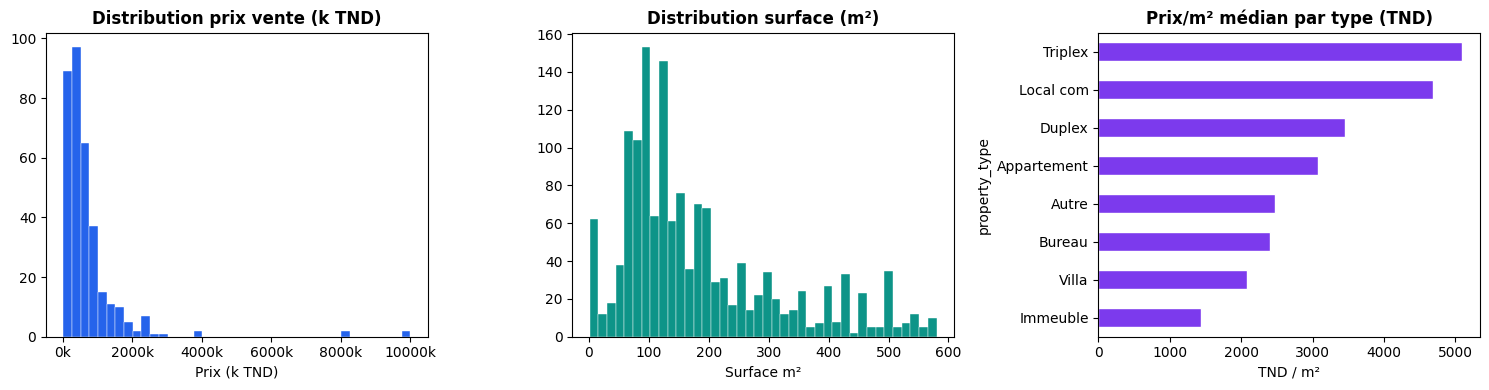


✓ Dataset nettoyé : 2,136 annonces
  dont Vente    : 714
  dont Location : 590


In [15]:
# Visualisation du dataset nettoyé
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution prix (vente)
df_v = df[(df['transaction_type']=='Vente') & df['price'].notna()]
axes[0].hist(df_v['price'] / 1000, bins=40, color='#2563EB', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution prix vente (k TND)', fontweight='bold')
axes[0].set_xlabel('Prix (k TND)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Distribution surface
df_s = df[df['surface_m2'].notna() & (df['surface_m2'] < 600)]
axes[1].hist(df_s['surface_m2'], bins=40, color='#0D9488', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution surface (m²)', fontweight='bold')
axes[1].set_xlabel('Surface m²')

# Prix/m² par type de bien
pm2_plot = (
    df[df['price_per_m2'].between(100, 15_000) & (df['transaction_type']=='Vente')]
    .groupby('property_type')['price_per_m2'].median()
    .sort_values(ascending=False)
    .head(8)
)
pm2_plot.plot(kind='barh', ax=axes[2], color='#7C3AED', edgecolor='white')
axes[2].set_title('Prix/m² médian par type (TND)', fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlabel('TND / m²')

plt.tight_layout()
plt.show()

print(f'\n✓ Dataset nettoyé : {len(df):,} annonces')
print(f'  dont Vente    : {(df["transaction_type"]=="Vente").sum():,}')
print(f'  dont Location : {(df["transaction_type"]=="Location").sum():,}')

---
## PARTIE 3 — PRÉDICTION DE PRIX
### Objectif : entraîner un modèle qui prédit le prix d'un bien

Architecture du pipeline :
```
                         ┌─────────────────────────┐
Raw features             │   ColumnTransformer     │
  ├── numériques   ──►   │   ├── Imputer (median)  │
  └── catégoriels  ──►   │   └── OneHotEncoder     │   ──►  Model
                         └─────────────────────────┘
```

**Modèles évalués**
| Modèle | Type | Avantage |
|---|---|---|
| Random Forest | Ensemble bagging | Robuste au bruit, stable |
| Extra Trees | Ensemble bagging | Plus rapide, moins variance |
| Gradient Boosting | Ensemble boosting | Meilleur sur données tabulaires |
| Huber Regressor | Linéaire robuste | Résistant aux outliers |

**Sélection finale** : VotingRegressor (moyenne des top 3 modèles)

In [16]:
!pip install xgboost lightgbm -q

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, VotingRegressor)
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score,
                              mean_squared_error, mean_absolute_percentage_error)
import xgboost as xgb
import lightgbm as lgb

print('✓ Sklearn + XGBoost + LightGBM importés')


✓ Sklearn + XGBoost + LightGBM importés


In [17]:
# ════════════════════════════════════════════════════════════
#  3.1 — PRÉPARATION DU DATASET ML
# ════════════════════════════════════════════════════════════
#
# On travaille sur les VENTES uniquement :
# → prix unique (pas de récurrence mensuelle)
# → plus grande variance de prix → plus facile à modéliser

FEATURES_NUM = [
    'surface_m2',    # surface brute
    'log_surface',   # surface log-transformée (distribution plus symétrique)
    'rooms_imp',     # nb pièces
    'bath_imp',      # nb SDB
    'ref_pm2',       # prix/m² médian du segment (feature la plus prédictive)
    'city_tier',     # tier de la ville (1-4)
    'is_furnished',  # meublé : flag 0/1
    'is_new',        # neuf   : flag 0/1
    'has_pool',      # piscine : flag 0/1
]
FEATURES_CAT = [
    'property_type',  # Appartement, Villa, Terrain...
    'surface_cat',    # bucket surface
]

# Filtrage : vente + prix valide + surface valide
df_ml = df[
    (df['transaction_type'] == 'Vente') &
    df['price'].notna() &
    df['surface_m2'].notna() &
    (df['surface_m2'] > 10)
].copy()

# Suppression outliers prix : IQR [10% — 90%]
p10, p90 = df_ml['price'].quantile([0.10, 0.90])
df_ml = df_ml[(df_ml['price'] >= p10) & (df_ml['price'] <= p90)]

# Suppression prix/m² aberrants
df_ml = df_ml[df_ml['price_per_m2'].between(100, 25_000)]

X = df_ml[FEATURES_NUM + FEATURES_CAT]
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Dataset ML (vente) : {len(df_ml)} annonces')
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Target — min: {y.min():,.0f} TND | médiane: {y.median():,.0f} TND | max: {y.max():,.0f} TND')

Dataset ML (vente) : 258 annonces
Train : 206 | Test : 52
Target — min: 140,000 TND | médiane: 460,000 TND | max: 1,400,000 TND


In [18]:
# ════════════════════════════════════════════════════════════
#  3.2 — PIPELINE SKLEARN + 6 MODELS
# ════════════════════════════════════════════════════════════

num_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_preprocessor, FEATURES_NUM),
    ('cat', cat_preprocessor, FEATURES_CAT),
])

MODELS = {
    # ── Original 4 ──────────────────────────────────────────
    'RandomForest':     RandomForestRegressor(
                            n_estimators=400, max_depth=10,
                            min_samples_leaf=2, random_state=42, n_jobs=-1),

    'ExtraTrees':       ExtraTreesRegressor(
                            n_estimators=400, max_depth=10,
                            min_samples_leaf=2, random_state=42, n_jobs=-1),

    'GradientBoosting': GradientBoostingRegressor(
                            n_estimators=300, max_depth=4,
                            learning_rate=0.05, subsample=0.8, random_state=42),

    'Huber':            HuberRegressor(epsilon=1.35, max_iter=500),

    # ── 2 New models ─────────────────────────────────────────
    'XGBoost':          xgb.XGBRegressor(
                            n_estimators=300, max_depth=5,
                            learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42,
                            verbosity=0, n_jobs=-1),

    'LightGBM':         lgb.LGBMRegressor(
                            n_estimators=300, max_depth=5,
                            learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42,
                            verbose=-1, n_jobs=-1),
}

print(f'✓ {len(MODELS)} models ready : {list(MODELS.keys())}')


✓ 6 models ready : ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'Huber', 'XGBoost', 'LightGBM']


In [19]:
# ════════════════════════════════════════════════════════════
#  3.3 — TRAINING + CROSS-VALIDATION (all 6 models)
# ════════════════════════════════════════════════════════════

kf      = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<18} {'CV-R²':>7} {'±':>6} {'R²-Test':>8} {'MAE (TND)':>12} {'RMSE':>12} {'MAPE':>8}")
print('─' * 78)

for name, model in MODELS.items():
    pipe  = Pipeline([('pre', preprocessor), ('model', model)])
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    pipe.fit(X_train, y_train)
    y_pred = np.clip(pipe.predict(X_test), 0, None)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[name] = {
        'pipeline':    pipe,
        'cv_r2_mean':  cv_r2.mean(),
        'cv_r2_std':   cv_r2.std(),
        'R2':          r2,
        'MAE':         mae,
        'RMSE':        rmse,
        'MAPE':        mape,
        'y_pred_test': y_pred,
    }
    print(f"{name:<18} {cv_r2.mean():>7.3f} {cv_r2.std():>6.3f} "
          f"{r2:>8.3f} {mae:>12,.0f} {rmse:>12,.0f} {mape:>7.1f}%")

best = max(results, key=lambda k: results[k]['R2'])
print(f'\n✓ Best single model : {best}  (R²={results[best]["R2"]:.3f})')


Model                CV-R²      ±  R²-Test    MAE (TND)         RMSE     MAPE
──────────────────────────────────────────────────────────────────────────────
RandomForest         0.148  0.128    0.209      203,995      268,577    41.2%
ExtraTrees           0.071  0.186   -0.013      222,387      303,879    41.1%
GradientBoosting    -0.121  0.274    0.136      213,132      280,610    43.6%
Huber                0.157  0.152    0.203      199,287      269,621    39.7%
XGBoost             -0.028  0.278    0.109      215,102      285,115    41.9%
LightGBM             0.179  0.145    0.160      212,012      276,786    44.8%

✓ Best single model : RandomForest  (R²=0.209)


In [20]:
# ════════════════════════════════════════════════════════════
#  3.4 — ENSEMBLE : VotingRegressor (top 3 by R² test)
# ════════════════════════════════════════════════════════════

top3 = sorted(results, key=lambda k: results[k]['R2'], reverse=True)[:3]
print(f'Top 3 selected : {top3}')

ensemble = VotingRegressor(
    estimators=[(name, results[name]['pipeline']) for name in top3]
)
ensemble.fit(X_train, y_train)

y_ens    = np.clip(ensemble.predict(X_test), 0, None)
ens_r2   = r2_score(y_test, y_ens)
ens_mae  = mean_absolute_error(y_test, y_ens)
ens_rmse = np.sqrt(mean_squared_error(y_test, y_ens))
ens_mape = mean_absolute_percentage_error(y_test, y_ens) * 100

print(f'\n🏆 Ensemble — R²={ens_r2:.3f} | MAE={ens_mae:,.0f} TND | '
      f'RMSE={ens_rmse:,.0f} TND | MAPE={ens_mape:.1f}%')


Top 3 selected : ['RandomForest', 'Huber', 'LightGBM']

🏆 Ensemble — R²=0.229 | MAE=199,322 TND | RMSE=265,136 TND | MAPE=40.8%


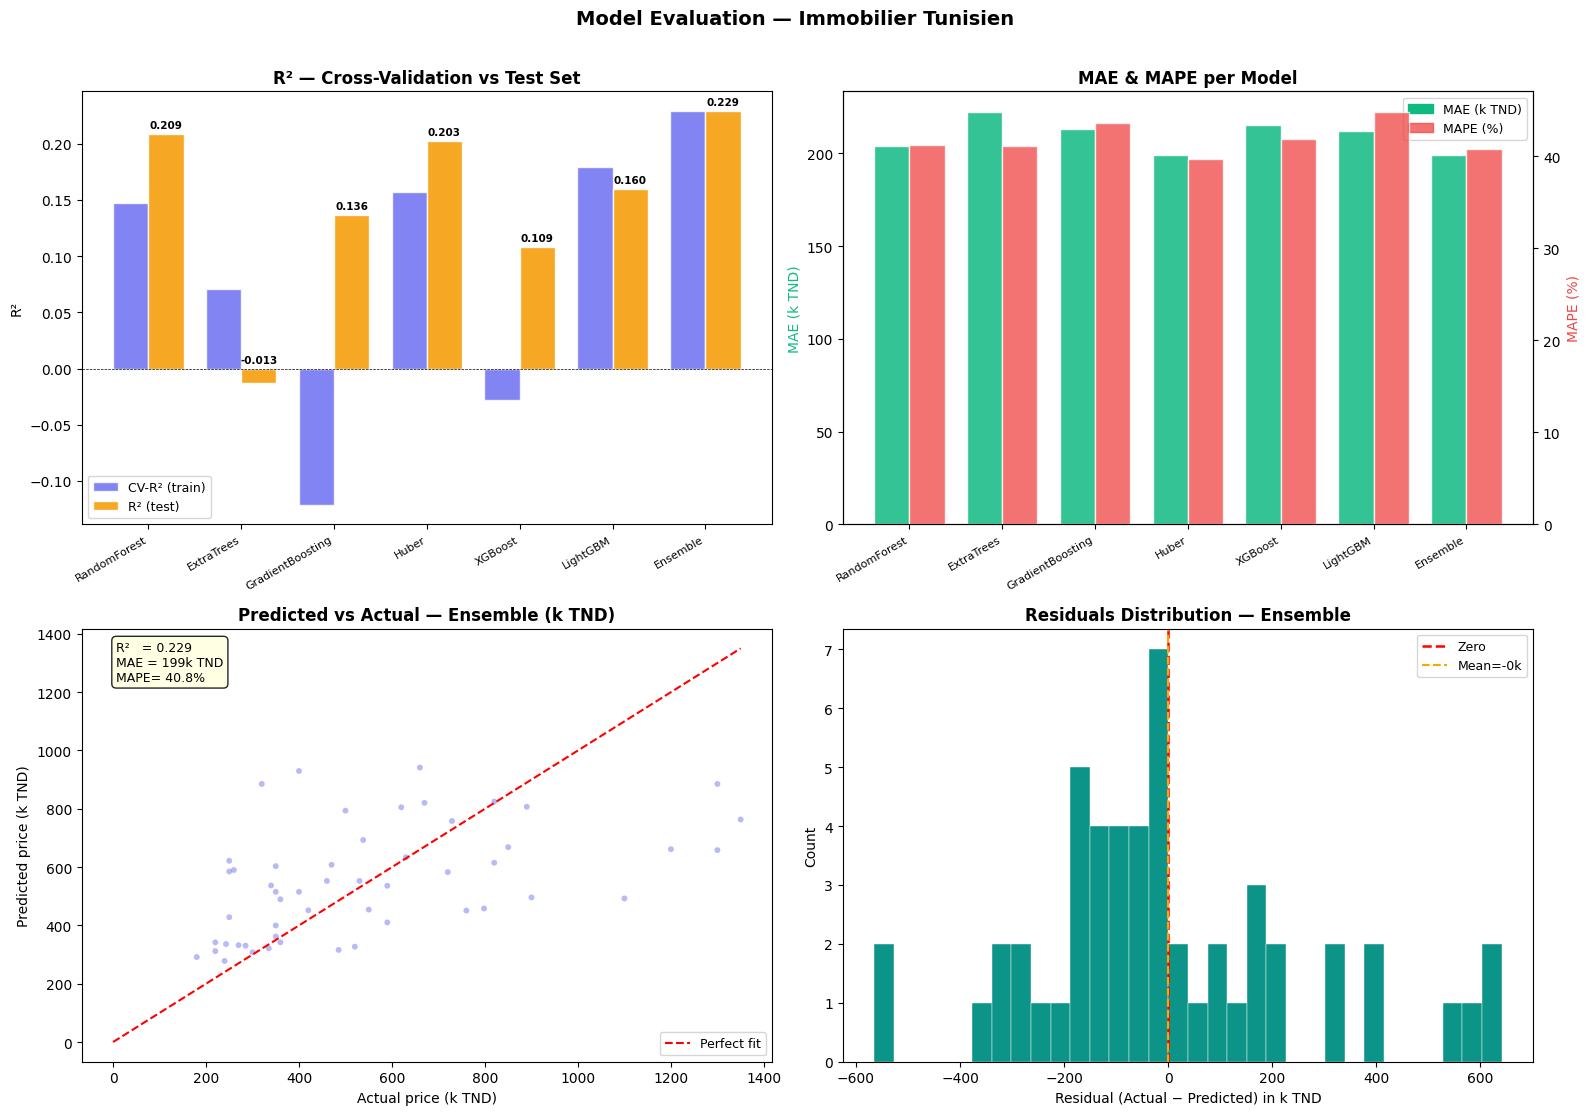


═══════════════════════════════════════════════════════════════════════════
  DETAILED EVALUATION — ALL MODELS
═══════════════════════════════════════════════════════════════════════════
  Model                CV-R²  R²-Test    MAE (TND)         RMSE     MAPE  Note
  ────────────────────────────────────────────────────────────────────────
  RandomForest         0.148    0.209      203,995      268,577    41.2%  ⚠️     Faible ◄ top3
  ExtraTrees           0.071   -0.013      222,387      303,879    41.1%  ⚠️     Faible
  GradientBoosting    -0.121    0.136      213,132      280,610    43.6%  ⚠️     Faible
  Huber                0.157    0.203      199,287      269,621    39.7%  ⭐     Acceptable ◄ top3
  XGBoost             -0.028    0.109      215,102      285,115    41.9%  ⚠️     Faible
  LightGBM             0.179    0.160      212,012      276,786    44.8%  ⚠️     Faible ◄ top3
  ────────────────────────────────────────────────────────────────────────
  🏆 Ensemble               —   

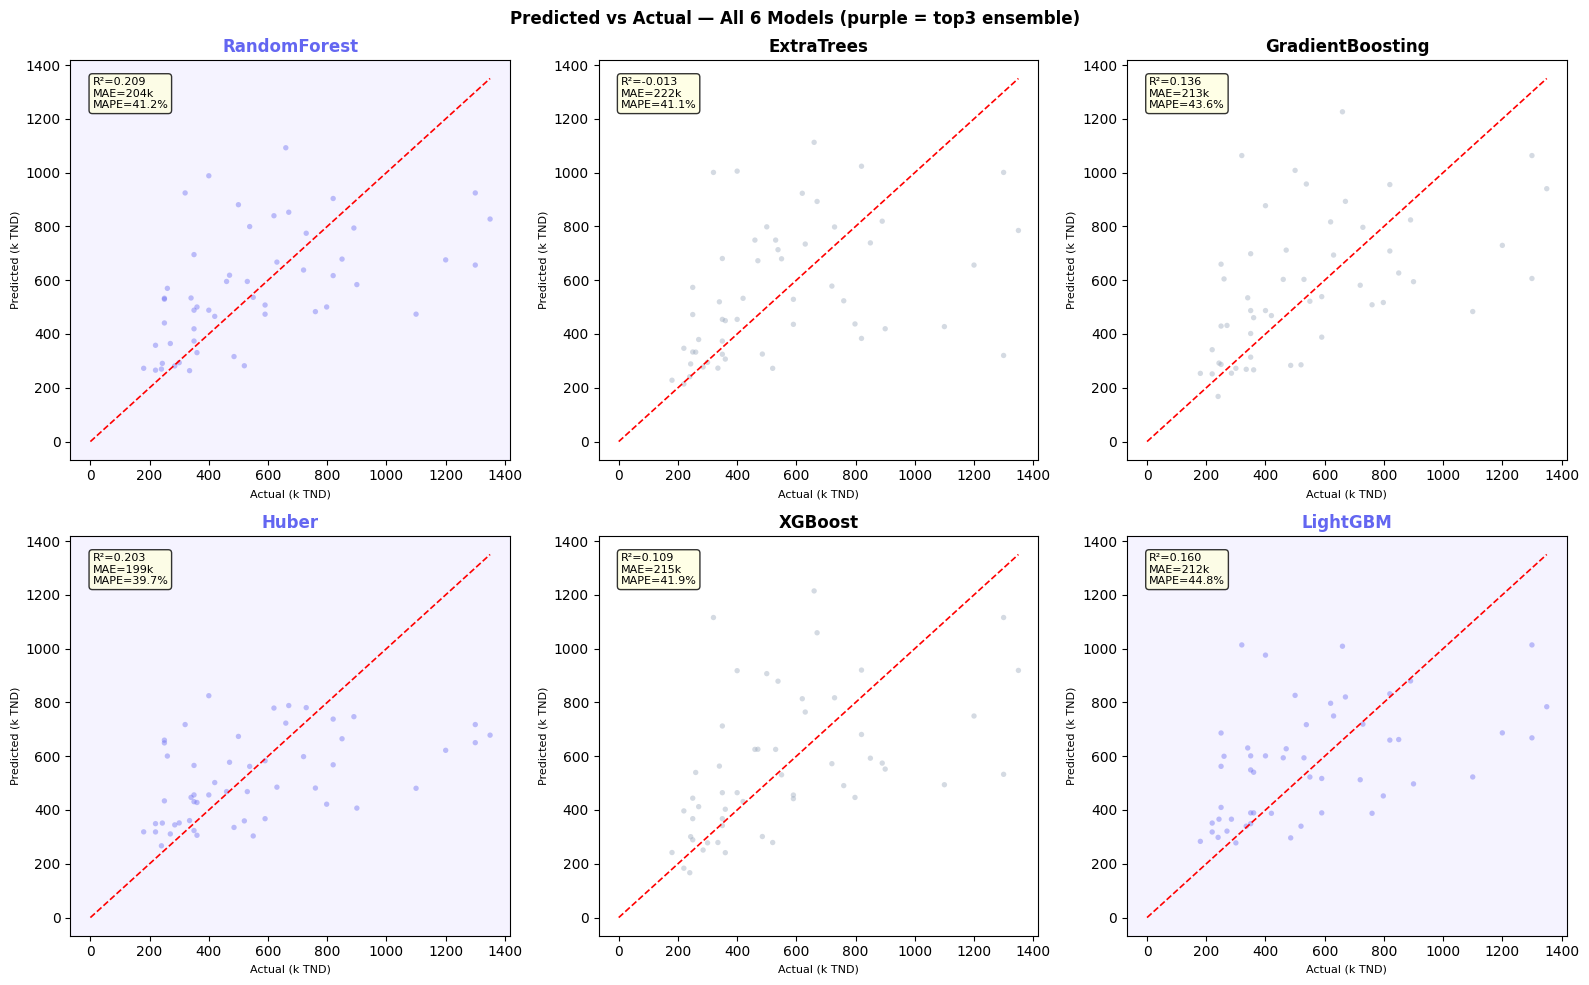

In [21]:
# ════════════════════════════════════════════════════════════
#  3.5 — FULL EVALUATION — 4 CHARTS PER MODEL
# ════════════════════════════════════════════════════════════

all_names = list(results.keys()) + ['Ensemble']
all_r2    = [results[m]['R2']   for m in results] + [ens_r2]
all_mae   = [results[m]['MAE']  for m in results] + [ens_mae]
all_rmse  = [results[m]['RMSE'] for m in results] + [ens_rmse]
all_mape  = [results[m]['MAPE'] for m in results] + [ens_mape]
all_cv    = [results[m]['cv_r2_mean'] for m in results] + [None]

colors_bar = ['#6366F1' if n in top3 else '#94A3B8' for n in results] + ['#F59E0B']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Model Evaluation — Immobilier Tunisien', fontsize=14, fontweight='bold', y=1.01)

# ── 1. R² comparison (CV vs Test) ──────────────────────────
x = np.arange(len(all_names))
w = 0.38
cv_vals = [results[m]['cv_r2_mean'] for m in results] + [ens_r2]
b1 = axes[0,0].bar(x - w/2, cv_vals,  w, label='CV-R² (train)', color='#6366F1', alpha=0.8, edgecolor='white')
b2 = axes[0,0].bar(x + w/2, all_r2,   w, label='R² (test)',     color='#F59E0B', alpha=0.9, edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(all_names, rotation=30, ha='right', fontsize=8)
axes[0,0].set_title('R² — Cross-Validation vs Test Set', fontweight='bold')
axes[0,0].set_ylabel('R²')
axes[0,0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0,0].legend(fontsize=9)
for bar, val in zip(b2, all_r2):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, max(val,0) + 0.005,
                   f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

# ── 2. MAE + MAPE dual axis ────────────────────────────────
ax_r = axes[0,1].twinx()
b3 = axes[0,1].bar(x - w/2, [v/1000 for v in all_mae], w,
                    label='MAE (k TND)', color='#10B981', alpha=0.85, edgecolor='white')
b4 = ax_r.bar(x + w/2, all_mape, w,
               label='MAPE (%)', color='#EF4444', alpha=0.75, edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(all_names, rotation=30, ha='right', fontsize=8)
axes[0,1].set_title('MAE & MAPE per Model', fontweight='bold')
axes[0,1].set_ylabel('MAE (k TND)', color='#10B981')
ax_r.set_ylabel('MAPE (%)', color='#EF4444')
lines = [plt.Rectangle((0,0),1,1,color='#10B981'),
         plt.Rectangle((0,0),1,1,color='#EF4444',alpha=0.75)]
axes[0,1].legend(lines, ['MAE (k TND)','MAPE (%)'], fontsize=9)

# ── 3. Predicted vs Actual — Ensemble ─────────────────────
axes[1,0].scatter(y_test/1000, y_ens/1000,
                  alpha=0.45, s=18, color='#6366F1', edgecolors='none')
lim = max(y_test.max(), y_ens.max()) / 1000
axes[1,0].plot([0,lim],[0,lim], 'r--', linewidth=1.5, label='Perfect fit')
axes[1,0].set_title('Predicted vs Actual — Ensemble (k TND)', fontweight='bold')
axes[1,0].set_xlabel('Actual price (k TND)')
axes[1,0].set_ylabel('Predicted price (k TND)')
axes[1,0].text(0.05, 0.88,
               f'R²   = {ens_r2:.3f}\nMAE = {ens_mae/1000:.0f}k TND\nMAPE= {ens_mape:.1f}%',
               transform=axes[1,0].transAxes, fontsize=9,
               bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow', alpha=0.85))
axes[1,0].legend(fontsize=9)

# ── 4. Residuals distribution ──────────────────────────────
residuals = y_test.values - y_ens
axes[1,1].hist(residuals/1000, bins=32, color='#0D9488', edgecolor='white', linewidth=0.3)
axes[1,1].axvline(0,                      color='red',    linestyle='--', linewidth=1.8, label='Zero')
axes[1,1].axvline(np.mean(residuals)/1000, color='orange', linestyle='--', linewidth=1.5,
                   label=f'Mean={np.mean(residuals)/1000:.0f}k')
axes[1,1].set_title('Residuals Distribution — Ensemble', fontweight='bold')
axes[1,1].set_xlabel('Residual (Actual − Predicted) in k TND')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Per-model detailed evaluation table ───────────────────
print('\n' + '═'*75)
print('  DETAILED EVALUATION — ALL MODELS')
print('═'*75)
print(f"  {'Model':<18} {'CV-R²':>7} {'R²-Test':>8} {'MAE (TND)':>12} {'RMSE':>12} {'MAPE':>8}  {'Note'}")
print('  ' + '─'*72)

def model_note(r2, mape):
    if r2 >= 0.5  and mape <= 20: return '⭐⭐⭐  Excellent'
    if r2 >= 0.35 and mape <= 30: return '⭐⭐    Bon'
    if r2 >= 0.2  and mape <= 40: return '⭐     Acceptable'
    return '⚠️     Faible'

for name in results:
    r  = results[name]
    marker = ' ◄ top3' if name in top3 else ''
    note   = model_note(r['R2'], r['MAPE'])
    print(f"  {name:<18} {r['cv_r2_mean']:>7.3f} {r['R2']:>8.3f} "
          f"{r['MAE']:>12,.0f} {r['RMSE']:>12,.0f} {r['MAPE']:>7.1f}%  {note}{marker}")

print('  ' + '─'*72)
ens_note = model_note(ens_r2, ens_mape)
print(f"  {'🏆 Ensemble':<18} {'—':>7} {ens_r2:>8.3f} "
      f"{ens_mae:>12,.0f} {ens_rmse:>12,.0f} {ens_mape:>7.1f}%  {ens_note}")
print('═'*75)

# ── Per-model scatter plots ────────────────────────────────
print('\nPer-model Predicted vs Actual plots:')
n_models = len(results)
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
axes2 = axes2.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax  = axes2[idx]
    yp  = res['y_pred_test']
    lim = max(y_test.max(), yp.max()) / 1000
    ax.scatter(y_test/1000, yp/1000, alpha=0.4, s=15,
               color='#6366F1' if name in top3 else '#94A3B8',
               edgecolors='none')
    ax.plot([0,lim],[0,lim],'r--', linewidth=1.2)
    ax.set_title(f'{name}', fontweight='bold',
                 color='#6366F1' if name in top3 else 'black')
    ax.set_xlabel('Actual (k TND)', fontsize=8)
    ax.set_ylabel('Predicted (k TND)', fontsize=8)
    ax.text(0.05, 0.88,
            f"R²={res['R2']:.3f}\nMAE={res['MAE']/1000:.0f}k\nMAPE={res['MAPE']:.1f}%",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    if name in top3:
        ax.set_facecolor('#F5F3FF')

plt.suptitle('Predicted vs Actual — All 6 Models (purple = top3 ensemble)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


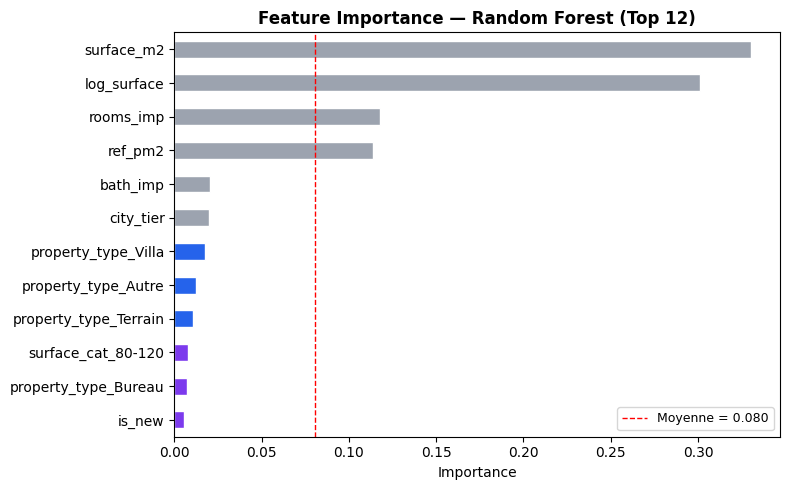

Top 5 features les plus importantes :
  surface_m2                0.3305  (33.0%)
  log_surface               0.3011  (30.1%)
  rooms_imp                 0.1179  (11.8%)
  ref_pm2                   0.1136  (11.4%)
  bath_imp                  0.0205  (2.1%)


In [22]:
# ════════════════════════════════════════════════════════════
#  3.6 — FEATURE IMPORTANCE (Random Forest)
# ════════════════════════════════════════════════════════════

rf_pipe   = results['RandomForest']['pipeline']
rf_model  = rf_pipe.named_steps['model']
pre_step  = rf_pipe.named_steps['pre']
ohe_names = list(pre_step.transformers_[1][1]
                 .named_steps['ohe']
                 .get_feature_names_out(FEATURES_CAT))
all_feat_names = FEATURES_NUM + ohe_names

fi = pd.Series(rf_model.feature_importances_, index=all_feat_names)
fi_top = fi.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['#7C3AED' if i < 3 else '#2563EB' if i < 6 else '#9CA3AF'
             for i in range(len(fi_top))]
fi_top.plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest (Top 12)', fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(fi_top.mean(), color='red', linestyle='--', linewidth=1, label=f'Moyenne = {fi_top.mean():.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 features les plus importantes :')
for feat, imp in fi_top.head(5).items():
    print(f'  {feat:<25} {imp:.4f}  ({imp*100:.1f}%)')

In [23]:
# ════════════════════════════════════════════════════════════
#  3.7 — PRÉDICTION SUR NOUVEAUX BIENS
# ════════════════════════════════════════════════════════════

def predict_price(surface_m2: float,
                  property_type: str = 'Appartement',
                  rooms: int = None,
                  city_tier: int = 1,
                  is_new: int = 0,
                  is_furnished: int = 0,
                  has_pool: int = 0) -> dict:
    """
    Prédit le prix d'un bien en TND.
    Retourne la prédiction de l'ensemble + intervalle de confiance approché.
    """
    # Imputation rooms si non fourni
    if rooms is None:
        rooms = max(1, round(surface_m2 / 25))

    input_data = pd.DataFrame([{
        'surface_m2':    surface_m2,
        'log_surface':   np.log1p(surface_m2),
        'rooms_imp':     rooms,
        'bath_imp':      max(0, round(rooms / 3)),
        'ref_pm2':       pm2_by_type.get(property_type, df['price_per_m2'].median()),
        'city_tier':     city_tier,
        'is_furnished':  is_furnished,
        'is_new':        is_new,
        'has_pool':      has_pool,
        'property_type': property_type,
        'surface_cat':   pd.cut([surface_m2],
                                bins=[0,50,80,120,200,400,20_000],
                                labels=['<50m²','50-80','80-120','120-200','200-400','>400m²'])[0],
    }])

    # Prédictions individuelles des 3 modèles
    preds = [np.clip(results[m]['pipeline'].predict(input_data)[0], 0, None) for m in top3]
    pred_ensemble = np.mean(preds)

    return {
        'prix_predit_TND':    round(pred_ensemble, -3),
        'intervalle_bas_TND': round(min(preds), -3),
        'intervalle_haut_TND':round(max(preds), -3),
        'prix_par_m2':        round(pred_ensemble / surface_m2),
    }


# ── Exemples de prédiction ──
exemples = [
    {'surface_m2': 120, 'property_type': 'Appartement', 'rooms': 4, 'city_tier': 1, 'is_new': 1},
    {'surface_m2': 300, 'property_type': 'Villa',       'rooms': 7, 'city_tier': 1, 'has_pool': 1},
    {'surface_m2':  60, 'property_type': 'Studio',      'rooms': 1, 'city_tier': 2},
    {'surface_m2': 500, 'property_type': 'Terrain',     'rooms': 0, 'city_tier': 3},
]

print(f'{"Description":<45} {"Prédit":>12} {"Bas":>12} {"Haut":>12} {"TND/m²":>8}')
print('─' * 92)
for ex in exemples:
    r = predict_price(**ex)
    desc = f"{ex['property_type']} {ex['surface_m2']}m² (tier {ex.get('city_tier',1)})"
    print(f"{desc:<45} {r['prix_predit_TND']:>12,.0f} "
          f"{r['intervalle_bas_TND']:>12,.0f} "
          f"{r['intervalle_haut_TND']:>12,.0f} "
          f"{r['prix_par_m2']:>8,.0f}")

Description                                         Prédit          Bas         Haut   TND/m²
────────────────────────────────────────────────────────────────────────────────────────────
Appartement 120m² (tier 1)                         367,000      294,000      453,000    3,055
Villa 300m² (tier 1)                               700,000      652,000      754,000    2,335
Studio 60m² (tier 2)                               425,000      414,000      446,000    7,077
Terrain 500m² (tier 3)                             460,000      365,000      540,000      920


In [24]:
# ════════════════════════════════════════════════════════════
#  3.8 — EXPORT XLSX (colonnes séparées, formaté)
# ════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

df_export = df[df['transaction_type'] == 'Vente'].copy()
has_surf  = df_export['surface_m2'].notna() & (df_export['surface_m2'] > 10)

df_export.loc[has_surf, 'prix_predit'] = np.clip(
    ensemble.predict(df_export.loc[has_surf, FEATURES_NUM + FEATURES_CAT]), 0, None
).round(-3)

df_export['ecart_pct'] = np.where(
    df_export['price'].notna() & df_export['prix_predit'].notna() & (df_export['prix_predit'] > 0),
    ((df_export['price'] - df_export['prix_predit']) / df_export['prix_predit'] * 100).round(1),
    np.nan
)
df_export['signal'] = df_export['ecart_pct'].apply(
    lambda x: '🟢 Sous-évalué' if pd.notna(x) and x < -20 else (
              '🟡 Prix marché' if pd.notna(x) and abs(x) <= 20 else (
              '🔴 Surévalué'   if pd.notna(x) else '⚪ Pas de prix'))
)

# Nettoyage
bad_titles = ['Vente','À PROPOS DE CE BIEN','PROPRIÉTÉS À VENDRE','Biens à la vente',
              'BALLOUCHI.COM','Liste des villas à vendre','Liste des triplex à vendre',
              'Liste des maisons ou villas à vendre','Liste Immeubles à vendre',
              'Liste des terrains à vendre','Les annonces des appartement à vendre']
df_export = df_export[~df_export['title'].str.strip().isin(bad_titles)]
residential = ['Appartement','Villa','Duplex','Studio','Penthouse','Maison','Loft','Triplex']
df_export = df_export[~(df_export['property_type'].isin(residential) & (df_export['surface_m2'] > 1000))]
df_export = df_export[df_export['ecart_pct'].isna() | df_export['ecart_pct'].between(-80, 200)]
df_export = df_export[df_export['prix_predit'].notna()].reset_index(drop=True)

# ── CRÉATION EXCEL ──
wb = Workbook()
ws = wb.active
ws.title = "Prédictions"
ws.sheet_view.showGridLines = False

NAVY='1B2A4A'; BLUE='2563EB'; GREEN='16A34A'; RED='DC2626'
YELLOW='D97706'; PURPLE='7C3AED'; WHITE='FFFFFF'; BLACK='111827'; GRAYLT='F3F4F6'

# Titre
ws.merge_cells('A1:I1')
c = ws['A1']
c.value = '🏠  PRÉDICTIONS PRIX — IMMOBILIER TUNISIEN'
c.font  = Font(name='Calibri', bold=True, color=WHITE, size=14)
c.fill  = PatternFill('solid', fgColor=NAVY)
c.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 36

ws.merge_cells('A2:I2')
c2 = ws['A2']
c2.value = f'{len(df_export)} annonces · Pipeline NLP + Ensemble ML'
c2.font  = Font(name='Calibri', color='9CA3AF', size=10)
c2.fill  = PatternFill('solid', fgColor='0F172A')
c2.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[2].height = 20
ws.row_dimensions[3].height = 8

# Headers
headers    = ['Titre','Type','Ville','Surface m²','Pièces','Prix Annoncé (TND)','Prix Prédit ML (TND)','Écart %','Signal']
col_widths = [45, 15, 15, 13, 8, 20, 22, 10, 18]
for j, (h, w) in enumerate(zip(headers, col_widths), 1):
    c = ws.cell(row=4, column=j, value=h)
    c.font      = Font(name='Calibri', bold=True, color=WHITE, size=9)
    c.fill      = PatternFill('solid', fgColor=BLUE)
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.column_dimensions[get_column_letter(j)].width = w
ws.row_dimensions[4].height = 22

SIGNAL_STYLE = {
    '🟢 Sous-évalué': ('DCFCE7', GREEN),
    '🟡 Prix marché':  ('FEFCE8', YELLOW),
    '🔴 Surévalué':    ('FEE2E2', RED),
    '⚪ Pas de prix':  (GRAYLT,  '6B7280'),
}

def safe_int(v): return int(v) if pd.notna(v) else None

for i, (_, row) in enumerate(df_export.iterrows()):
    r      = i + 5
    signal = str(row['signal'])
    row_bg, _ = SIGNAL_STYLE.get(signal, (GRAYLT, BLACK))
    alt_bg = 'F8FAFC' if i % 2 == 0 else WHITE
    ws.row_dimensions[r].height = 16

    vals   = [str(row['title']), str(row['property_type']),
              str(row['city']) if pd.notna(row['city']) else '',
              safe_int(row['surface_m2']), safe_int(row['rooms_imp']),
              safe_int(row['price']), safe_int(row['prix_predit']),
              round(float(row['ecart_pct']), 1) if pd.notna(row['ecart_pct']) else None,
              signal]
    fmts   = [None,None,None,'#,##0 "m²"','0','#,##0','#,##0','0.0"%"',None]
    aligns = ['left','center','left','center','center','right','right','center','center']

    for j, (v, fmt, al) in enumerate(zip(vals, fmts, aligns), 1):
        c = ws.cell(row=r, column=j, value=v)
        c.font      = Font(name='Calibri', size=9, color=BLACK)
        c.alignment = Alignment(horizontal=al, vertical='center')
        c.border    = Border(bottom=Side(style='thin', color='E5E7EB'))
        c.fill      = PatternFill('solid', fgColor=row_bg if signal != '⚪ Pas de prix' else alt_bg)
        if fmt: c.number_format = fmt
        if j == 6 and v: c.font = Font(name='Calibri', size=9, color=NAVY,   bold=True)
        if j == 7 and v: c.font = Font(name='Calibri', size=9, color=PURPLE, bold=True)
        if j == 8 and v is not None:
            c.font = Font(name='Calibri', size=9, bold=abs(v)>20,
                          color=RED if v > 20 else (GREEN if v < -20 else BLACK))
        if j == 9:
            _, fg = SIGNAL_STYLE.get(signal, (GRAYLT, BLACK))
            c.font = Font(name='Calibri', size=9, color=fg, bold=True)

ws.freeze_panes = 'A5'
ws.auto_filter.ref = f'A4:{get_column_letter(9)}{len(df_export)+4}'

wb.save('predictions_immobilier_tn.xlsx')
print(f'✓ {len(df_export)} annonces exportées')

from google.colab import files
files.download('predictions_immobilier_tn.xlsx')

✓ 512 annonces exportées


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ════════════════════════════════════════════════════════════

print('=' * 70)
print('  PIPELINE SUMMARY — IMMOBILIER TUNISIEN')
print('=' * 70)
print(f'  Raw data           : {len(df_raw):,} listings')
print(f'  Tunisia (clean)    : {len(df):,} listings')
print(f'  With valid price   : {df["price"].notna().sum():,}')
print(f'  ML dataset (sale)  : {len(df_ml):,}')
print(f'  Features           : {len(FEATURES_NUM)} numeric + {len(FEATURES_CAT)} categorical')
print()
print(f"  {'Model':<18} {'R²-Test':>8} {'MAE (TND)':>12} {'MAPE':>8}")
print('  ' + '─' * 52)
for name in results:
    marker = ' ◄ top3' if name in top3 else ''
    print(f"  {name:<18} {results[name]['R2']:>8.3f} "
          f"{results[name]['MAE']:>12,.0f} "
          f"{results[name]['MAPE']:>7.1f}%{marker}")
print('  ' + '─' * 52)
print(f"  {'🏆 Ensemble':<18} {ens_r2:>8.3f} {ens_mae:>12,.0f} {ens_mape:>7.1f}%")
print('=' * 70)


  PIPELINE SUMMARY — IMMOBILIER TUNISIEN
  Raw data           : 3,680 listings
  Tunisia (clean)    : 2,136 listings
  With valid price   : 1,158
  ML dataset (sale)  : 258
  Features           : 9 numeric + 2 categorical

  Model               R²-Test    MAE (TND)     MAPE
  ────────────────────────────────────────────────────
  RandomForest          0.209      203,995    41.2% ◄ top3
  ExtraTrees           -0.013      222,387    41.1%
  GradientBoosting      0.136      213,132    43.6%
  Huber                 0.203      199,287    39.7% ◄ top3
  XGBoost               0.109      215,102    41.9%
  LightGBM              0.160      212,012    44.8% ◄ top3
  ────────────────────────────────────────────────────
  🏆 Ensemble            0.229      199,322    40.8%


In [26]:
import sklearn
print(sklearn.__version__)  # note cette version

1.6.1


In [27]:
import joblib

bundle = {
    'model':        ensemble,
    'features_num': FEATURES_NUM,
    'features_cat': FEATURES_CAT,
    'pm2_by_type':  dict(pm2_by_type),
    'global_pm2':   float(df['price_per_m2'].median()),
    'metrics': {
        'R2':   round(ens_r2,  4),
        'MAE':  round(ens_mae, 0),
        'RMSE': round(ens_rmse,0),
    }
}

joblib.dump(bundle, 'model_immo.pkl')
print('✓ model_immo.pkl sauvegardé')

from google.colab import files
files.download('model_immo.pkl')
files.download('predictions_immobilier_tn.xlsx')

✓ model_immo.pkl sauvegardé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>